# Redes Neuronales con SckitLearn

In [28]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Dataset de dígitos (0-9, imágenes de 8x8 pixeles)
#https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits
digits = load_digits()

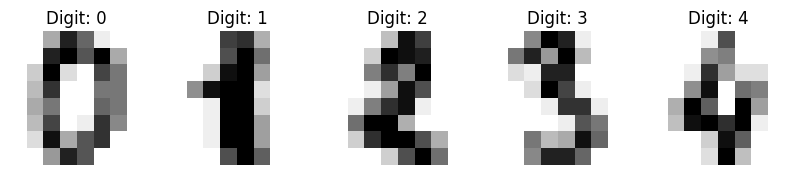

In [9]:
images = digits.images
targets = digits.target

# Display the first few images
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
for ax, image, label in zip(axes, images, targets):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Digit: {label}")
plt.show()

In [ ]:
X, y = load_digits(return_X_y=True)

In [3]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [4]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [10]:
#https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html
# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Red neuronal (Perceptrón Multicapa con 2 capas ocultas)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Evaluación
y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.94      0.97      0.96        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      1.00      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



Confusion matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  2  0  0  0  0  1 37]]


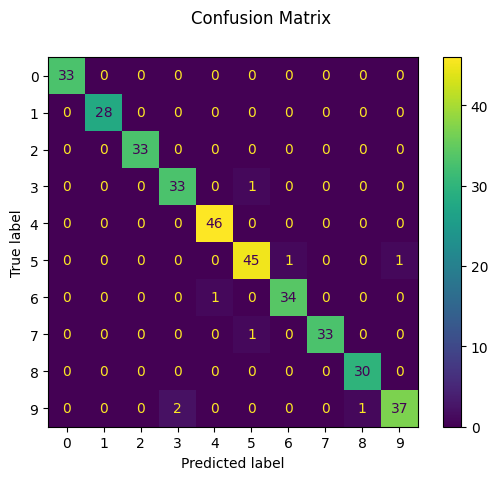

In [12]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

# Uso básico de TensorFlow y Keras

+ TensorFlow: framework de bajo nivel para operaciones numéricas y deep learning.
+ Keras: API de alto nivel para construir y entrenar modelos en TensorFlow (desde TF 2.x ya está integrado).

In [ ]:
#!pip3 install tensorflow

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

#https://www.tensorflow.org/datasets/catalog/mnist?hl=es-419
# Cargar datos
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

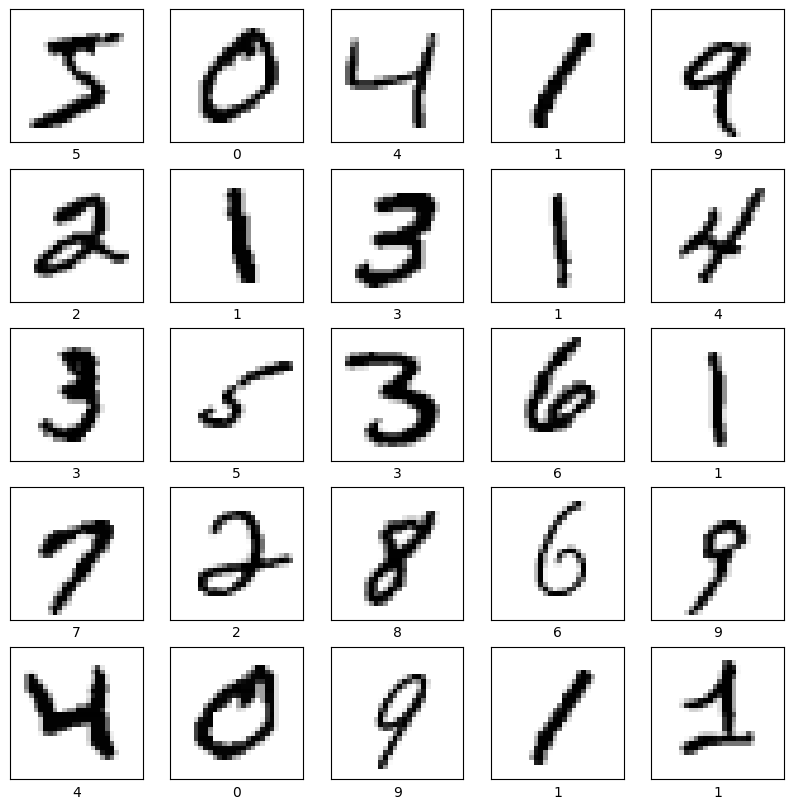

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25): # Display the first 25 images
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary) # Display in grayscale
    plt.xlabel(y_train[i]) # Show the label as the x-axis label
plt.show()

In [ ]:
# Normalizar
x_train, x_test = x_train / 255.0, x_test / 255.0

# Construcción del modelo
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9265 - loss: 0.2596 - val_accuracy: 0.9581 - val_loss: 0.1370
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step - accuracy: 0.9661 - loss: 0.1154 - val_accuracy: 0.9562 - val_loss: 0.1376
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 921us/step - accuracy: 0.9764 - loss: 0.0790 - val_accuracy: 0.9740 - val_loss: 0.0822
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.9815 - loss: 0.0599 - val_accuracy: 0.9752 - val_loss: 0.0783
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - accuracy: 0.9861 - loss: 0.0458 - val_accuracy: 0.9764 - val_loss: 0.0738


In [39]:
#Uso de TensorBoard
import datetime

# Definir log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# Entrenar con TensorBoard
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test),
          callbacks=[tensorboard_callback])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9982 - loss: 0.0063 - val_accuracy: 0.9781 - val_loss: 0.0947
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9979 - loss: 0.0071 - val_accuracy: 0.9797 - val_loss: 0.0976
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9976 - loss: 0.0068 - val_accuracy: 0.9796 - val_loss: 0.0957
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 0.9771 - val_loss: 0.1003
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9789 - val_loss: 0.0993


In [41]:
!tensorboard --logdir=logs/fit --port=6006
#http://localhost:6006/

TensorFlow installation not found - running with reduced feature set.
Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.17.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


In [ ]:
!lsof -i:6006

COMMAND   PID                USER   FD   TYPE             DEVICE SIZE/OFF NODE NAME
Python  11963 carlosvasquezguerra    3u  IPv4 0xef2978adcfe76b79      0t0  TCP localhost:6006 (LISTEN)


In [37]:
!kill -9 11963

In [42]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Modelos avanzados con TensorFlow/Keras

## Perceptrón Multicapa (MLP)

Clasificación de dígitos: Datos MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_test = x_train.reshape(-1, 784), x_test.reshape(-1, 784)

mlp_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mlp_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

mlp_model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Reporte
y_pred = np.argmax(mlp_model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred))

Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 841us/step - accuracy: 0.9143 - loss: 0.2928 - val_accuracy: 0.9533 - val_loss: 0.1577
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.9612 - loss: 0.1308 - val_accuracy: 0.9642 - val_loss: 0.1181
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 690us/step - accuracy: 0.9712 - loss: 0.0965 - val_accuracy: 0.9650 - val_loss: 0.1195
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.9755 - loss: 0.0780 - val_accuracy: 0.9719 - val_loss: 0.0919
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.9803 - loss: 0.0630 - val_accuracy: 0.9692 - val_loss: 0.1066
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.96      0.98      0.

## Red Neuronal Convolucional (CNN)

Clasificación de imágenes con convoluciones

Datos MNIST con canal de color :

+ Una imagen en escala de grises (como MNIST) tiene 1 canal → (28, 28, 1)
+ Una imagen en color RGB tiene 3 canales → (altura, ancho, 3)
+ Una imagen en color RGBA tendría 4 canales → (altura, ancho, 4)

In [47]:
print(x_train.shape)

(60000, 784)


In [ ]:
#60,000 imágenes de 28x28 (sin canal explícito)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape)

(60000, 28, 28)


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
x_train, x_test = x_train[..., None], x_test[..., None]

In [50]:
#CNN esperan 4D tensors con formato (n_imágenes, altura, ancho, canales)
print(x_train.shape)

(60000, 28, 28, 1)


In [ ]:
# Modelo CNN
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cnn_model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

# Reporte
y_pred = np.argmax(cnn_model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred))


Epoch 1/3


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9607 - loss: 0.1266 - val_accuracy: 0.9820 - val_loss: 0.0555
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9879 - loss: 0.0407 - val_accuracy: 0.9902 - val_loss: 0.0327
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9915 - loss: 0.0269 - val_accuracy: 0.9913 - val_loss: 0.0285
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99     

## Red Neuronal Recurrente (RNN - LSTM)

Analisis de sentimientos sobre IMBD

In [ ]:
from tensorflow.keras.preprocessing import sequence

# https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data
# Dataset IMDB
max_features = 10000  # vocabulario
max_len = 200         # tamaño secuencia

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [53]:
y_train

array([1, 0, 0, ..., 0, 1, 0])

In [55]:
# Padding
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

1. Padding en redes convolucionales (CNNs)

Cuando se aplica un filtro (kernel) sobre una imagen, se van perdiendo bordes. Padding significa “rellenar” la imagen con ceros (o algún valor) en los bordes, para que la convolución no reduzca demasiado el tamaño de la salida.

Ejemplo sin padding
+ Imagen: 5x5
+ Filtro: 3x3
+ Salida: 3x3 (se pierde información de bordes).

```layers.Conv2D(32, (3,3), padding='valid')  # sin padding (default)```

Ejemplo con padding = 1

+ Se rellena la imagen con un marco de 1 píxel de ceros → imagen 7x7
+ Aplicando el filtro 3x3 se obtiene una salida 5x5 (tamaño igual al original).

```layers.Conv2D(32, (3,3), padding='same')```

2. Padding en secuencias de texto (NLP, RNNs)

En procesamiento de lenguaje natural, cada oración puede tener distinta longitud y las redes (RNN, LSTM, Transformers) necesitan entradas de igual tamaño, así que se rellena (padding) con ceros hasta un máximo definido.

Ejemplo sin padding
+ [5, 8, 2]              → oración de 3 palabras
+ [3, 7, 9, 1, 4]        → oración de 5 palabras

Ejemplo con padding
+ [0, 0, 5, 8, 2, 0]
+ [3, 7, 9, 1, 4, 0]

```
sequences = [[5, 8, 2], [3, 7, 9, 1, 4]]
padded = pad_sequences(sequences, maxlen=6, padding='post')
print(padded)
```

In [56]:
# Modelo RNN (LSTM)
rnn_model = models.Sequential([
    layers.Embedding(max_features, 64, input_length=max_len),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

rnn_model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))

# Reporte
y_pred = (rnn_model.predict(x_test) > 0.5).astype("int32").flatten()
print(classification_report(y_test, y_pred))

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - accuracy: 0.7885 - loss: 0.4431 - val_accuracy: 0.8670 - val_loss: 0.3157
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.8873 - loss: 0.2799 - val_accuracy: 0.8716 - val_loss: 0.3089
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



## Generative Adversarial Network (GAN)

Un GAN (Generative Adversarial Network) consiste en dos redes entrenando juntas:
+ El Generador (G)
    - Toma ruido aleatorio (un vector z) y produce una imagen sintética.
    - Inicialmente, las imágenes son solo ruido.
    - Su objetivo: generar imágenes que el discriminador no pueda diferenciar de las reales.
+ El Discriminador (D)
    - Toma imágenes (reales de MNIST o generadas por G) y predice si son reales (1) o falsas (0).
    - Su objetivo: clasificar correctamente las imágenes reales y las falsas.

El entrenamiento es un “juego de suma cero”
+ G quiere que D se equivoque → “engañar al discriminador”.
+ D quiere no dejarse engañar → clasificar bien.

Esto se traduce en pérdidas:
+ Loss del discriminador: 
    - $L_D = -[log(D(real)) + log(1 - D(fake))]$
    - Maximiza cuando D clasifica correctamente reales y falsas.
+ Loss del generador:
    - $L_G = -log(D(fake))$
    - Minimiza cuando D clasifica las imágenes generadas como reales.

La intuición es la siguiente: 

Inicialmente, G genera ruido, D aprende fácil y con cada epoch:
+ G mejora sus imágenes → se parecen más a dígitos reales.
+ D también mejora → aprende a distinguir mejor.

Después de varias iteraciones, G genera imágenes que parecen reales y D no puede diferenciarlas confiablemente.

Es un “juego de engaño”:
+ D actúa como “profesor” que corrige a G.
+ G aprende a crear ejemplos convincentes porque recibe retroalimentación de D.

![](img/GANSpreview-tb-f1fb529.png)

Generación de imagenes en MNIST

In [58]:
import os
from tensorflow.keras import optimizers

In [104]:
# Datos MNIST normalizados entre -1 y 1
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1) # Añadir canal

batch_size = 128
latent_dim = 100

output_dir = "gan_output"
os.makedirs(output_dir, exist_ok=True)

In [106]:
# Generador
#generator = models.Sequential([
#    layers.Dense(128, activation="relu", input_shape=(latent_dim,)),
#    layers.Dense(28*28, activation="tanh"),
#    layers.Reshape((28,28,1))
#])

generator = models.Sequential([
    layers.Dense(7*7*128, activation="relu", input_shape=(latent_dim,)),
    layers.Reshape((7,7,128)),
    layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding="same", activation="relu"),
    layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding="same", activation="tanh")
])

# Discriminador
#discriminator = models.Sequential([
#    layers.Flatten(input_shape=(28,28,1)),
#    layers.Dense(128, activation="relu"),
#    layers.Dense(1, activation="sigmoid")
#])
discriminator = models.Sequential([
    layers.Conv2D(64, (5,5), strides=(2,2), padding="same", input_shape=(28,28,1)),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])


discriminator.compile(optimizer=optimizers.Adam(0.0002), 
                      loss="binary_crossentropy", 
                      metrics=["accuracy"])

# GAN (Generador + Discriminador)
discriminator.trainable = False
# Latent vector (z): vector aleatorio (ej. 100 dimensiones) que el generador transforma en una imagen.
z = layers.Input(shape=(latent_dim,))
# Generador (G): toma z y produce una imagen sintética (aquí 28×28×1). Su objetivo: engañar al discriminador.
img = generator(z)
# Discriminador (D): clasificador binario que recibe una imagen real o generada y devuelve una puntuación (logit). Su objetivo: diferenciar reales de falsas.
validity = discriminator(img)

gan = models.Model(z, validity)
gan.compile(optimizer=optimizers.Adam(0.0002, beta_1=0.5), loss="binary_crossentropy")

In [107]:
#Función para guarda imágenes
def save_generated_images(epoch, n=16):
    noise = np.random.normal(0, 1, (n, latent_dim))
    gen_imgs = generator.predict(noise)

    # Escalar de [-1,1] a [0,1] para mostrar
    gen_imgs = 0.5 * gen_imgs + 0.5

    plt.figure(figsize=(4,4))
    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(gen_imgs[i,:,:,0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"epoch_{epoch}.png"))
    plt.close()
    print(f"Imágenes guardadas en {output_dir}/epoch_{epoch}.png")

In [108]:
# Entrenamiento simplificado
# Se alternan actualizaciones de D y G. D aprende a distinguir, G aprende a producir imágenes que D marque como reales.
for epoch in range(1, 401):  # Cantidad de imagenes a generar
    # Batch real
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    # Batch fake
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise)

    # Entrenamos al discriminador con imágenes reales y falsas.
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)) * 0.9) #label smoothing: Esto ayuda a estabilizar.
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    # Entrenamos al generador para engañar al discriminador.
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    # Entrenamos el generador 2 veces por cada epoch
    for _ in range(2): 
        g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    print(f"Epoch {epoch}: D loss real={d_loss_real}, D loss fake={d_loss_fake}, G loss={g_loss}")
    # Guardar imágenes generadas
    save_generated_images(epoch)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoch 1: D loss real=[array(0.6156434, dtype=float32), array(0., dtype=float32)], D loss fake=[array(0.65427065, dtype=float32), array(0.26171875, dtype=float32)], G loss=0.6902117133140564
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Imágenes guardadas en gan_output/epoch_1.png
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Epoch 2: D loss real=[array(0.64728093, dtype=float32), array(0.17447917, dtype=float32)], D loss fake=[array(0.6612486, dtype=float32), array(0.13085938, dtype=float32)], G loss=0.6848560571670532
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Imágenes guardadas en gan_output/epoch_2.png
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Epoch 3: D loss real=[array(0.6536559, dtype=float32), array(0.1046875, dtype=float32)], D loss fake=[array(0.66404444, dtype=float32), array(0.08723959, dtype=float32)], G loss=0.678929328918457
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Imágenes guardadas en gan_output/epoch_3.png
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Epoch 4: D loss 

In [80]:
import imageio

image_folder = "gan_output"
gif_name = "gan_evolution.gif"

# Ordenamos las imágenes por epoch
images = []
file_names = sorted([f for f in os.listdir(image_folder) if f.endswith(".png")])

for filename in file_names:
    file_path = os.path.join(image_folder, filename)
    images.append(imageio.imread(file_path))

# Guardamos GIF
imageio.mimsave(gif_name, images, duration=1)  # duration=1 seg por frame
print(f"GIF generado: {gif_name}")


/var/folders/yh/q32p31yd1951k9bflq1glbr80000gn/T/ipykernel_97232/2375123959.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


GIF generado: gan_evolution.gif


# Procesamiento de Lenguaje Natural (NLP)

Preprocesamiento con SpaCy

In [ ]:
#https://spacy-io.translate.goog/models?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc&_x_tr_hist=true
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm")
text = "John is studying at the University of Toronto. He loves machine learning!"
doc = nlp(text)

In [115]:
# Tokenización y Lematización
for token in doc:
    print(token.text, "->", token.lemma_)

John -> John
is -> be
studying -> study
at -> at
the -> the
University -> University
of -> of
Toronto -> Toronto
. -> .
He -> he
loves -> love
machine -> machine
learning -> learning
! -> !


In [116]:
# POS Tagging
print([(token.text, token.pos_) for token in doc])

[('John', 'PROPN'), ('is', 'AUX'), ('studying', 'VERB'), ('at', 'ADP'), ('the', 'DET'), ('University', 'PROPN'), ('of', 'ADP'), ('Toronto', 'PROPN'), ('.', 'PUNCT'), ('He', 'PRON'), ('loves', 'VERB'), ('machine', 'NOUN'), ('learning', 'NOUN'), ('!', 'PUNCT')]


In [117]:
# Eliminar Stopwords
tokens = [token.lemma_ for token in doc if token.text.lower() not in STOP_WORDS and token.is_alpha]
print(tokens)

['John', 'study', 'University', 'Toronto', 'love', 'machine', 'learning']


Stemming con NLTK

In [121]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/carlosvasquezguerra/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [122]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()
tokens = word_tokenize("studies studying studied")
print([stemmer.stem(word) for word in tokens])


['studi', 'studi', 'studi']


# Machine Learning para NLP

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn import svm
from sklearn.metrics import accuracy_score

#https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset
# Dataset de newsgroups
data = fetch_20newsgroups(subset='train', categories=['sci.space','rec.sport.hockey'])
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42)

## Term Frequency – Inverse Document Frequency.
TF-IDF Es una técnica de vectorización de texto, que convierte palabras en números para que los algoritmos de machine learning puedan trabajar con ellas.

+ TF (Term Frequency): frecuencia de una palabra en un documento.
    - Se calcula como: $TF(t,d) = \frac{número de veces que aparece t en d}{total de palabras en d}$
    - Ejemplo: si “perro” aparece 3 veces en un texto de 100 palabras, TF = 3/100 = 0.03.
+ IDF (Inverse Document Frequency): mide qué tan rara o importante es una palabra en todo el corpus.
    - Se calcula como:$IDF(t)=log\frac{N}{1+DF(t)}$ donde:
        * N = número total de documentos
        * $DF(t)$ = número de documentos donde aparece la palabra t
    - Palabras muy comunes (“el”, “y”, “de”) tendrán IDF bajo → menos peso.
    - Palabras raras tendrán IDF alto → más peso.
+ TF-IDF = TF * IDF: Multiplicando TF por IDF obtenemos un valor que refleja la importancia de la palabra en un documento, considerando todo el corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "el perro corre en el parque",
    "el gato duerme en la casa",
    "el perro y el gato juegan juntos"
]

# Crear vectorizador TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

# Palabras del vocabulario
print(vectorizer.get_feature_names_out())

# Matriz TF-IDF
print(X.toarray())

In [125]:
# Vectorización TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [126]:
# ---- Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("Naive Bayes:", accuracy_score(y_test, nb.predict(X_test_tfidf)))

Naive Bayes: 0.9860335195530726


In [127]:
# ---- SVM
clf = svm.LinearSVC()
clf.fit(X_train_tfidf, y_train)
print("SVM:", accuracy_score(y_test, clf.predict(X_test_tfidf)))

SVM: 0.9888268156424581


# Red Neuronal para Sentiment Analysis con Keras

In [142]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('datasets/IMDB Dataset.csv')

In [146]:
df_sample = df.sample(10000).reset_index(drop=True)

SpaCy para limpiar y lematizar el texto

In [ ]:
import spacy
import re

# Cargar el modelo de SpaCy
nlp = spacy.load("en_core_web_sm")

# Función de limpieza y lematización
def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar caracteres no alfanuméricos
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Procesar el texto con SpaCy
    doc = nlp(text)
    # Lematizar y eliminar stopwords
    return ' '.join([token.lemma_ for token in doc if not token.is_stop])

# Aplicar la función de limpieza
df_sample['cleaned_review'] = df_sample['review'].apply(clean_text)

KeyboardInterrupt: 

Convertimos el texto limpio en secuencias de enteros

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Inicializar el tokenizador
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['cleaned_review'])

# Convertir texto a secuencias
X = tokenizer.texts_to_sequences(df['cleaned_review'])

# Rellenar las secuencias para que tengan la misma longitud
X = pad_sequences(X, maxlen=500)

# Etiquetas
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values

Creamos y compilamos el modelo LSTM

In [ ]:
from tensorflow.keras import models, layers

# Construir el modelo
model = models.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=500),
    layers.LSTM(128),
    layers.Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

Entrenamiento de los datos

In [ ]:
model.fit(X, y, epochs=5, batch_size=64, validation_split=0.2)

array([[0, 0, 0, 0, 0, 0, 3, 4, 1, 2],
       [0, 0, 0, 0, 0, 0, 1, 2, 5, 6]], dtype=int32)

Evaluación del modelo y generación de un reporte de clasificación

In [ ]:
from sklearn.metrics import classification_report

# Realizar predicciones
y_pred_prob = model.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)

# Generar el reporte de clasificación
print(classification_report(y, y_pred, target_names=['Negative', 'Positive']))